In [1]:
import numpy as np

In [2]:
#Function: kmeans_algo
#Input: int k, ipdata is a numpy array with each row for a gene having 208 values, 
#centroids is a numpy array with each row as a centroid having 208 values and there are k rows in total.
#Output: main_cluster is a numpy array with each row as a cluster.
#Each cluster is a numpy array of gene ids and there are total k rows in main_cluster.
#all_obj_func_val is a list of objective function values for each iteration of the kmeans
#Description: This is the top level function for kmeans.

def kmeans_algo(k,ipdata,centroids):
    
    iternum = 1
    all_obj_func_val = []
    
    while True:
        
        #print(iternum)
        iternum += 1
    
        #find the euclidean dists. for all ipdata[i] and centroids
        dists = euclid(ipdata, centroids)
    
        #find min. dist for each gene and assign to clusters
        main_cluster = assignCluster(dists)
        
        #find value of objective function
        obj_func_val = getObjFuncVal(dists, main_cluster)
        all_obj_func_val.append(obj_func_val)
    
        #find the new centroids
        new_centroids = calcCentroids(ipdata, main_cluster)
    
        #check for stop criterion
        if centroidsEqual(centroids, new_centroids) == True:
            break
        else:
            #update centroids to new_centroids
            
            centroids = new_centroids
            
            #clear main cluster (not needed as gets reassigned above)
            continue
            
    return main_cluster, all_obj_func_val

In [3]:
#Function: euclid
#Input: ipdata is a numpy array with each row for a gene having 208 values,
#centroids is a numpy array with each row as a centroid having 208 values and there are k rows in total.
#Output: opdists is numpy array with each row corresponding to a gene and each row has k values - each value is euclidean dist
#between the gene and each of the k centroids.
#Description: Calc. the euclidean distance between each gene row in ipdata and each of the k centroids in centroids numpy array

def euclid(ipdata,centroids):
    
    num_genes = len(ipdata)
    k = len(centroids)
    
    opdists = np.zeros((num_genes, k)) #initialization
    
    for i,g in enumerate(ipdata): #g is numpy array (208,) shape which is the gene vector
        dist_g_to_k = np.zeros((k,)) #initialized empty row for each gene, this row will be appended to the main opdists for each gene
        
        for j,c in enumerate(centroids): #c is numpy array (208,) shape which is the centroid vector
            dist_g_to_c = np.linalg.norm(g - c)
            dist_g_to_k[j] = dist_g_to_c
            
        opdists[i] = dist_g_to_k
            
    return opdists

In [4]:
#Function assignCluster
#Input: dists is a numpy array with each row corresponding to a gene and each row has k values - each value is euclidean dist
#between the gene and each of the k centroids.
#Output: opmain_cluster is a numpy array with each row as a cluster.
#Each cluster is a numpy array of gene ids and there are total k rows in main_cluster.
#Description: find min. dist from the k centroids for each gene and assign to one of the k clusters

def assignCluster(dists):
    
    #Let opmain_cluster be a list of lists for now, will convert it to numpy array at last as the number of rows is fixed to k but
    #number of columns is variable for each row or each cluster
    
    k = len(dists[0])
    opmain_cluster = [[] for _ in range(k)]
    
    for gid, d in enumerate(dists):
        cluster_num = np.argmin(d)
        opmain_cluster[cluster_num].append(gid)     
    
    return opmain_cluster


In [5]:
#Function: calcCentroids
#Input: main_cluster is a numpy array with each row as a cluster.
#Each cluster is a numpy array of gene ids and there are total k rows in main_cluster.
#ipdata is a numpy array with each row for a gene having 208 values.
#Output: opnew_centroids is a numpy array with each row as a centroid having 208 values and there are k rows in total.
#Description: find new centroids of the clusters formed

def calcCentroids(ipdata, main_cluster):
    
    k = len(main_cluster)
    num_samples = len(ipdata[0]) #208
    opnew_centroids = []
    
    for c in main_cluster:
        c_expr_mat = getExprMat(c, ipdata) #c is a 1D numpy array of gene ids in cluster c
        #c_expr_mat is a numpy array with rows as the genes and columns are 208 values, obtained from ipdata
        
        #find the centroid of the cluster c from the c_expr_mat
        cent = np.mean(c_expr_mat, axis=0) #cent is 1D numpy array with 208 values
        
        opnew_centroids.append(cent) #list of 1D numpy arrays
        
    opnew_centroids = np.asarray(opnew_centroids) #convert list to numpy array
    
    return opnew_centroids
    

In [6]:
#Function getExprMat
#Input: curr_c is the current cluster which is a 1D numpy array of gene ids
#ipdata is a numpy array with each row for a gene having 208 values.
#Output: opc_expr_mat is a numpy array with rows as the genes in curr_c and columns are 208 values
#Description: using the gene ids in the kth cluster, get the expression matrix from the ipdata

def getExprMat(curr_c, ipdata):
    
    opc_expr_mat = []
    
    for gid in curr_c:
        gene_vec = ipdata[gid]
        opc_expr_mat.append(gene_vec)
        
    opc_expr_mat = np.asarray(opc_expr_mat)
    
    return opc_expr_mat

In [7]:
#Function centroidsEqual
#Input: 2 sets of centroids, oldc, newc, each is a numpy array with each row as a centroid having 208 values and there are k rows in total.
#Output: boolean true or false
#Description: checks if the two sets of centroids are equal or not

def centroidsEqual(oldc, newc):
    
    for i,cent in enumerate(oldc):
        for j,val in enumerate(cent):
            if newc[i][j] == val:
                continue
            else:
                return False
            
    return True

In [8]:
#Function getObjFuncVal
#Input: dists is numpy array with each row corresponding to a gene and each row has k values - each value is euclidean dist
#between the gene and each of the k centroids.
#main_cluster is a numpy array with each row as a cluster.
#Each cluster is a numpy array of gene ids and there are total k rows in main_cluster.
#Output: a single float value, finalVal
#Description: using the clusters in the current iteration, find the objective function value for k means which is
#the sum of squares of euclidean distances between each gene vector and its cluster centroid vector

def getObjFuncVal(dists, main_cluster):
    
    finalVal = 0.0
    
    for i,c in enumerate(main_cluster):
        for g in c:
            nearest_dist = dists[g][i]
            finalVal += nearest_dist * nearest_dist
            
    return finalVal

In [9]:
#data prep

#read expression data
lines = []
with open('mouse-data/hip1000.txt') as f:
    lines = f.readlines()

#read gene names
lines2 = []
with open('mouse-data/hip1000names.txt') as f:
    lines2 = f.readlines()

gene_names = [line.strip().split(",") for line in lines2]

gene_names_final = [gene for gene in gene_names[0]]

expression_matrix = [line.strip().split(",") for line in lines]

#read test means

lines3 = []
with open('test_mean.txt') as f:
    lines3 = f.readlines()

lines3_matrix = [line.strip().split("   ") for line in lines3]

lines3_matrix2 = [float(num) for row in lines3_matrix for num in row]

n = len(lines3_matrix2)
mean1 = [lines3_matrix2[i] for i in range(0,n,3)]
mean2 = [lines3_matrix2[i] for i in range(1,n,3)]
mean3 = [lines3_matrix2[i] for i in range(2,n,3)]

for i in range(len(expression_matrix)):
    for j in range(len(expression_matrix[0])):
        nf = expression_matrix[i][j]
        nf = float(nf)
        expression_matrix[i][j] = nf

expr_mat_final = np.asarray(expression_matrix)

m1 = np.asarray(mean1)

m2 = np.asarray(mean2)
m3 = np.asarray(mean3)

gene_names_final2 = np.asarray(gene_names_final)

expr_mat_final2 = expr_mat_final.transpose()

final_cents = [m1,m2,m3]
final_cents = np.asarray(final_cents)

#final i/p: expr_mat_final2, final_cents

In [35]:
#Question 4a.

In [10]:
myfinalcluster, finalobjvals = kmeans_algo(3, expr_mat_final2, final_cents)

In [11]:
print(finalobjvals)

[170968.5174944616, 109058.75463863283, 103168.99480162043, 103009.47330276546]


In [12]:
import matplotlib.pyplot as plt

In [13]:
plot_X = [i+1 for i in range(len(finalobjvals))]

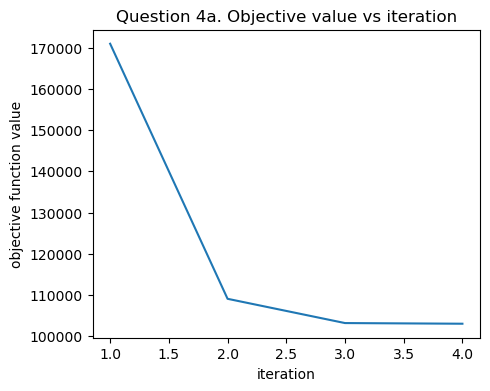

In [14]:
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(4)
plt.plot(plot_X, finalobjvals)

plt.xlabel("iteration")
plt.ylabel("objective function value")
plt.title("Question 4a. Objective value vs iteration")
plt.show()

4a answer: the objective value at convergence is 103009.47330276546

In [36]:
#Question 4b.

In [15]:
corrcoef1 = np.corrcoef(expr_mat_final2)

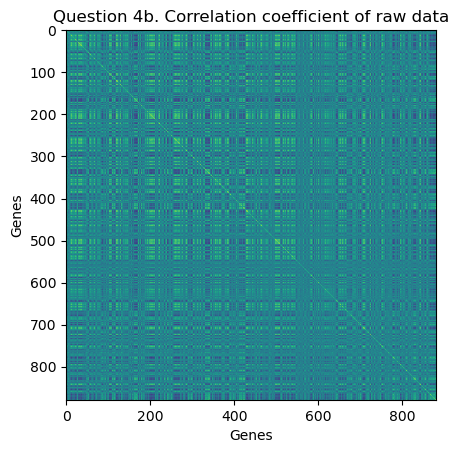

In [16]:
plt.xlabel("Genes")
plt.ylabel("Genes")
plt.title("Question 4b. Correlation coefficient of raw data")
plt.imshow(corrcoef1)
plt.show()

In [17]:
#Function: groupDataByClustering
#Input: finalCluster is a numpy array with each row as a cluster.
#Each cluster is a numpy array of gene ids and there are total k rows in main_cluster.
#ipdata is a numpy array with each row for a gene having 208 values.
#Output: opdata is a numpy array with each row for a gene having 208 values.
#Description: group data according to clustering

def groupDataByClustering(finalCluster, ipdata):
    
    opdata = []
    
    for c in finalCluster:
        for g in c:
            gene_vec = ipdata[g]
            opdata.append(gene_vec)
            
    opdata = np.asarray(opdata)
    return opdata


In [19]:
import random

In [20]:
#Function: getRandomCentroids
#Input: ipdata is a numpy array with each row for a gene having 208 values.
#int k
#Output: opcentroids is a numpy array with each row as a centroid having 208 values and there are k rows in total.
#Description: get k centroids from the input data to be taken as the random k means intialization

def getRandomCentroids(ipdata, k, some_i):
    
    opcentroids = []
    
    #make a list of k random gene ids
    
    num_genes = len(ipdata)
    exc = [4]
    if some_i not in exc:
        #print(10*some_i)
        random.seed(10*some_i)
    else:
        random.seed(1)
    rgid = [random.randint(0,num_genes-1) for _ in range(k)]
    #print(rgid)
    
    for g in rgid:
        gene_vec = ipdata[g]
        opcentroids.append(gene_vec)
        
    opcentroids = np.asarray(opcentroids)
    
    return opcentroids

In [21]:
randCentroids = getRandomCentroids(expr_mat_final2, 3, 1)

In [22]:
myfinalcluster2, finalobjvals2 = kmeans_algo(3, expr_mat_final2, randCentroids)

In [23]:
opdata2 = groupDataByClustering(myfinalcluster2, expr_mat_final2)

In [24]:
corrcoef3 = np.corrcoef(opdata2)

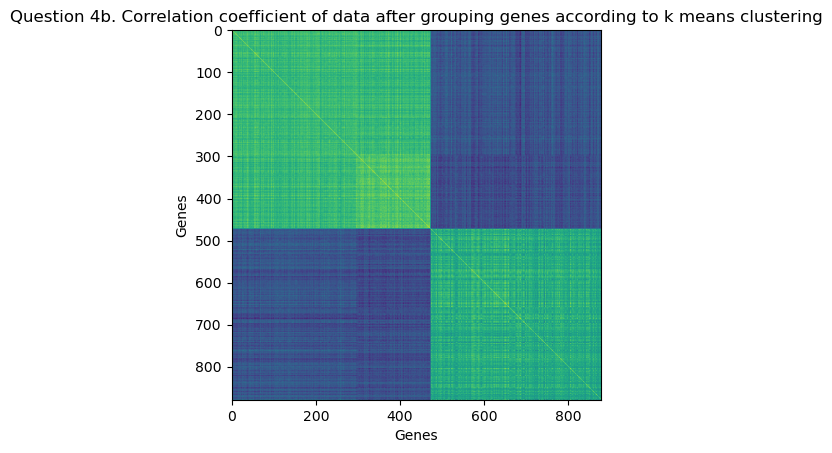

In [25]:
plt.xlabel("Genes")
plt.ylabel("Genes")
plt.title("Question 4b. Correlation coefficient of data after grouping genes according to k means clustering")
plt.imshow(corrcoef3)
plt.show()

In [26]:
#Question 4c
#K = 3, try 10 random initializations
#correlation coefficient matrix as above and the corresponding objective at convergence for each initialization

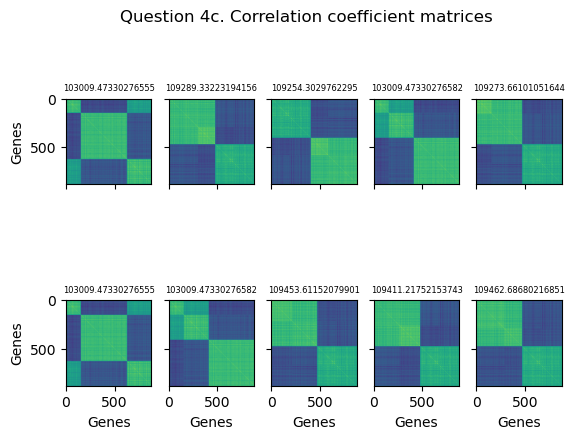

In [27]:
list_of_corr_coef = []
list_of_obj_val = []

fig, axs = plt.subplots(2,5, sharey = True)

for i in range(10):
    
    #print('initialization num: ',i+1)
    
    randCentroids2 = getRandomCentroids(expr_mat_final2, 3, i)
    myfinalcluster3, finalobjvals3 = kmeans_algo(3, expr_mat_final2, randCentroids2)
    
    #print('Objective values', finalobjvals3)
    list_of_obj_val.append(finalobjvals3[-1])
    
    opdata3 = groupDataByClustering(myfinalcluster3, expr_mat_final2)
    corrcoef4 = np.corrcoef(opdata3)
    list_of_corr_coef.append(corrcoef4)

fig.suptitle('Question 4c. Correlation coefficient matrices')
for ax in axs.flat:
    ax.set(xlabel='Genes', ylabel='Genes')
for ax in axs.flat:
    ax.label_outer()

r = 0
for m in range(2):
    for n in range(5):
        axs[m][n].set_title(list_of_obj_val[r], fontsize=6)
        axs[m][n].imshow(list_of_corr_coef[r])
        r += 1

4c answer: I would choose the initializations which give the least objective function value for follow-up analysis. In this case, it would be the
first and sixth initializations (sixth is bottom row first matrix).

In [28]:
#Question 4d
#K = 3, . . . , 12, with 10 random initializations
#correlation coefficient matrix and objectives at convergence for different K, with your best choice of the 10 runs for each K

In [29]:
def findBestCorrMat(k):
    list_of_corr_coef = []
    list_of_obj_val = []

    for i in range(10):
    
        #print('initialization num: ',i+1)
    
        randCentroids2 = getRandomCentroids(expr_mat_final2, k, i)
        myfinalcluster3, finalobjvals3 = kmeans_algo(k, expr_mat_final2, randCentroids2)
    
        #print('Objective values', finalobjvals3)
        list_of_obj_val.append(finalobjvals3[-1])
    
        opdata3 = groupDataByClustering(myfinalcluster3, expr_mat_final2)
        corrcoef4 = np.corrcoef(opdata3)
        list_of_corr_coef.append(corrcoef4)
        
    best_obj_val = min(list_of_obj_val)
    best_init_index = list_of_obj_val.index(best_obj_val)
    best_corr_coef = list_of_corr_coef[best_init_index]
    #print('list of objective values for all 10 iterations for this k: ',list_of_obj_val)
    print('the best (min) obj val from the above list: ', best_obj_val)
    print('best iteration num for this k: ', best_init_index)
    
    return k,best_obj_val,best_corr_coef

some_k: 3
the best (min) obj val from the above list:  103009.47330276555
best iteration num for this k:  0
some_k: 4
the best (min) obj val from the above list:  100355.7678085769
best iteration num for this k:  5
some_k: 5
the best (min) obj val from the above list:  98829.40871868207
best iteration num for this k:  4
some_k: 6
the best (min) obj val from the above list:  97547.98330205258
best iteration num for this k:  9
some_k: 7
the best (min) obj val from the above list:  96343.95294926521
best iteration num for this k:  9
some_k: 8
the best (min) obj val from the above list:  95193.44217834449
best iteration num for this k:  2
some_k: 9
the best (min) obj val from the above list:  94588.72942331879
best iteration num for this k:  2
some_k: 10
the best (min) obj val from the above list:  94029.29412578196
best iteration num for this k:  2
some_k: 11
the best (min) obj val from the above list:  93147.53003353946
best iteration num for this k:  6
some_k: 12
the best (min) obj val 

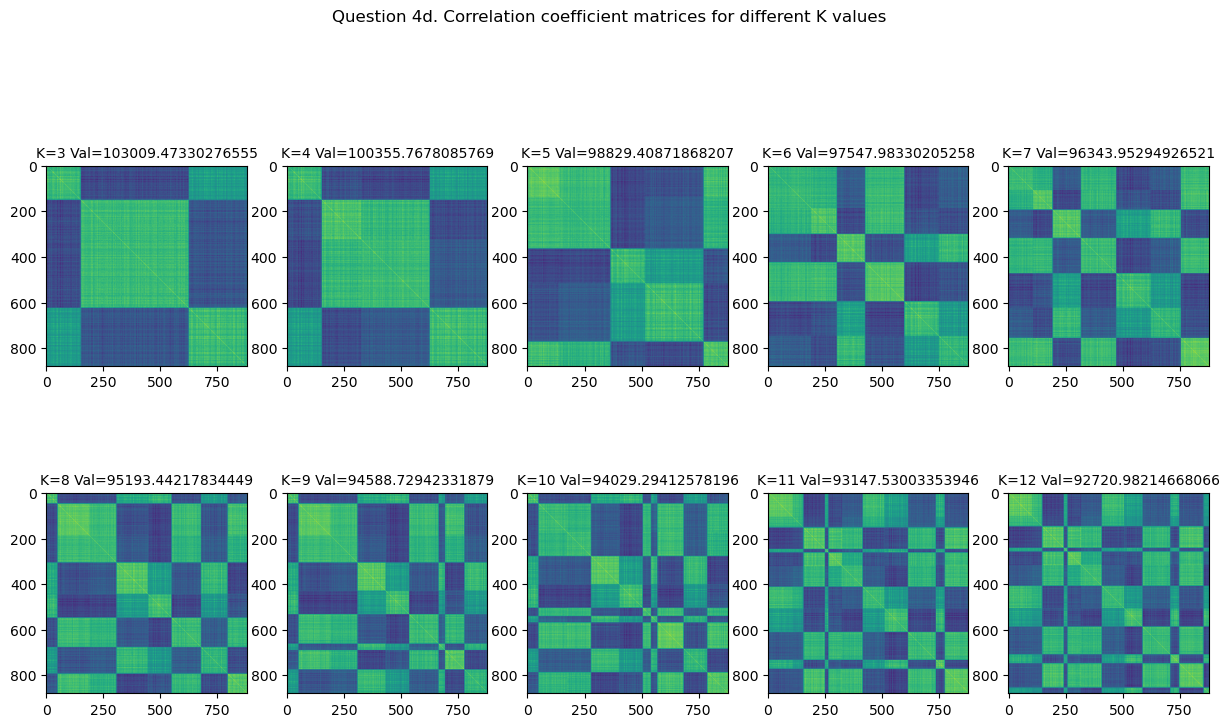

In [30]:

#fig, axs = plt.subplots(2,5, figsize=(15,15), sharey=True, constrained_layout = True)
fig, axs = plt.subplots(2,5, figsize=(15,15))
some_str = 'Question 4d. Correlation coefficient matrices for different K values'
fig.suptitle(some_str)
m = 0
n = 0
check_Y = []
for some_k in range(3,13):
    print('some_k:',some_k)
    if some_k == 8:
        m = 1
        n = 0
    fk,fval,fmat = findBestCorrMat(some_k)
    check_Y.append(fval)
    some_str2 = 'K=' + str(fk) + ' Val=' + str(fval) 
    axs[m][n].set_title(some_str2, fontsize=10)
    axs[m][n].imshow(fmat)
    n+=1
#plt.subplots_adjust(top=1, bottom=0.5)
plt.subplots_adjust(top=0.9, bottom=0.5)
plt.show()

In [31]:
print(check_Y)

[103009.47330276555, 100355.7678085769, 98829.40871868207, 97547.98330205258, 96343.95294926521, 95193.44217834449, 94588.72942331879, 94029.29412578196, 93147.53003353946, 92720.98214668066]


In [32]:
check_X = [x for x in range(3,13)]

In [33]:
print(check_X)

[3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


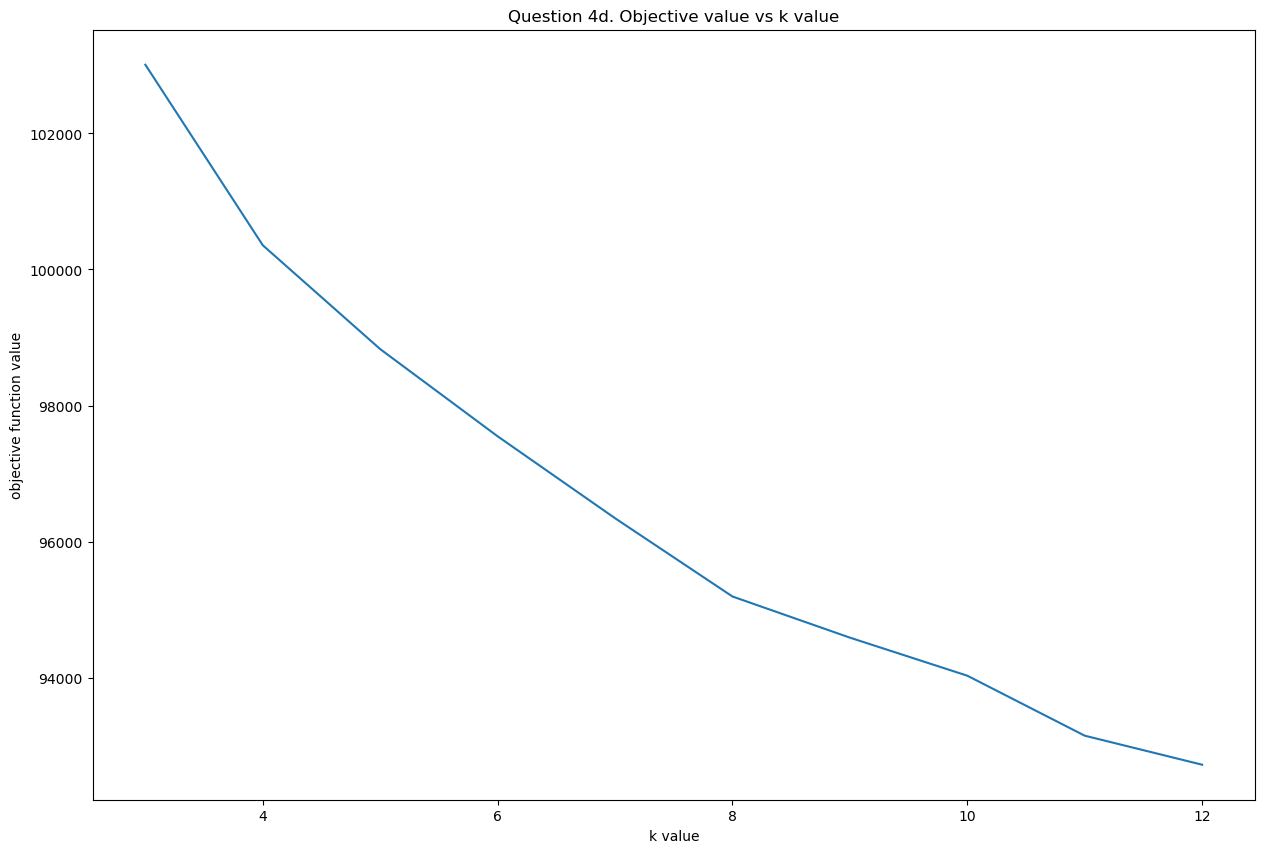

In [34]:
f = plt.figure()
f.set_figwidth(15)
f.set_figheight(10)
plt.plot(check_X, check_Y)

plt.xlabel("k value")
plt.ylabel("objective function value")
plt.title("Question 4d. Objective value vs k value")
plt.show()